# Wine Quality: End-to-End ML Pipeline

Binary classification of red wine quality (`quality >= 6` = good, `quality < 6` = bad) using a leakage-safe sklearn `Pipeline`. Class balance is close to even (53.5% good / 46.5% bad), so F1 is used as the primary metric mainly for a cleaner read on the harder-to-separate quality boundary, with accuracy and ROC-AUC as secondary checks. This isn't because of imbalance. `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` is used for every cross-validation comparison.

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Data Loading & Target Binarisation

`quality_label` is defined once here (1 if `quality >= 6`, else 0) and reused everywhere downstream. The raw `quality` column is dropped from `X` since it's the source of the label.

In [2]:
df = pd.read_csv('../data/winequality-red.csv')
df['quality_label'] = (df['quality'] >= 6).astype(int)

y = df['quality_label']
X = df.drop(columns=['quality', 'quality_label'])

## EDA Recap

Adapted from the dataset-selection notebook, reusing `df`/`quality_label` rather than reloading or re-binarising.

### Missing Values

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0]

if missing_df.empty:
    print("No missing values.")
else:
    print(missing_df.sort_values('pct', ascending=False))

No missing values.


### Target Variable & Class Balance

In [4]:
print("Target column: 'quality_label'")
print(f"Unique values: {sorted(df['quality_label'].unique())}")
print()
print("Raw distribution:")
print(df['quality_label'].value_counts())
print()
print("Proportions:")
print(df['quality_label'].value_counts(normalize=True).round(4))

Target column: 'quality_label'
Unique values: [np.int64(0), np.int64(1)]

Raw distribution:
quality_label
1    855
0    744
Name: count, dtype: int64

Proportions:
quality_label
1    0.5347
0    0.4653
Name: proportion, dtype: float64


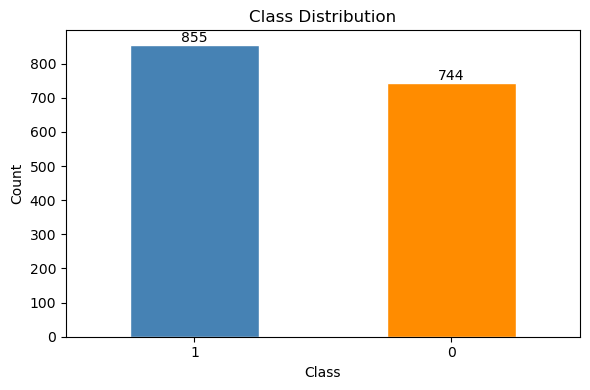

In [5]:
# Class balance bar chart
fig, ax = plt.subplots(figsize=(6, 4))
df['quality_label'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'],
                                          edgecolor='white', width=0.5)
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height()):,}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Descriptive Statistics

In [6]:
df.describe().T.style.background_gradient(subset=['mean', 'std'], cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.000000,8.319637,1.741096,4.600000,7.100000,7.900000,9.200000,15.900000
volatile acidity,1599.000000,0.527821,0.179060,0.120000,0.390000,0.520000,0.640000,1.580000
citric acid,1599.000000,0.270976,0.194801,0.000000,0.090000,0.260000,0.420000,1.000000
residual sugar,1599.000000,2.538806,1.409928,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,1599.000000,0.087467,0.047065,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,1599.000000,15.874922,10.460157,1.000000,7.000000,14.000000,21.000000,72.000000
total sulfur dioxide,1599.000000,46.467792,32.895324,6.000000,22.000000,38.000000,62.000000,289.000000
density,1599.000000,0.996747,0.001887,0.990070,0.995600,0.996750,0.997835,1.003690
pH,1599.000000,3.311113,0.154386,2.740000,3.210000,3.310000,3.400000,4.010000
sulphates,1599.000000,0.658149,0.169507,0.330000,0.550000,0.620000,0.730000,2.000000


In [7]:
# Check for any extreme skew
skewness = df.drop(columns=['quality', 'quality_label']).skew().sort_values(ascending=False)
print("Feature skewness (|skew| > 1 is notable):")
print(skewness[skewness.abs() > 1])

Feature skewness (|skew| > 1 is notable):
chlorides               5.680347
residual sugar          4.540655
sulphates               2.428672
total sulfur dioxide    1.515531
free sulfur dioxide     1.250567
dtype: float64


### Feature Distributions

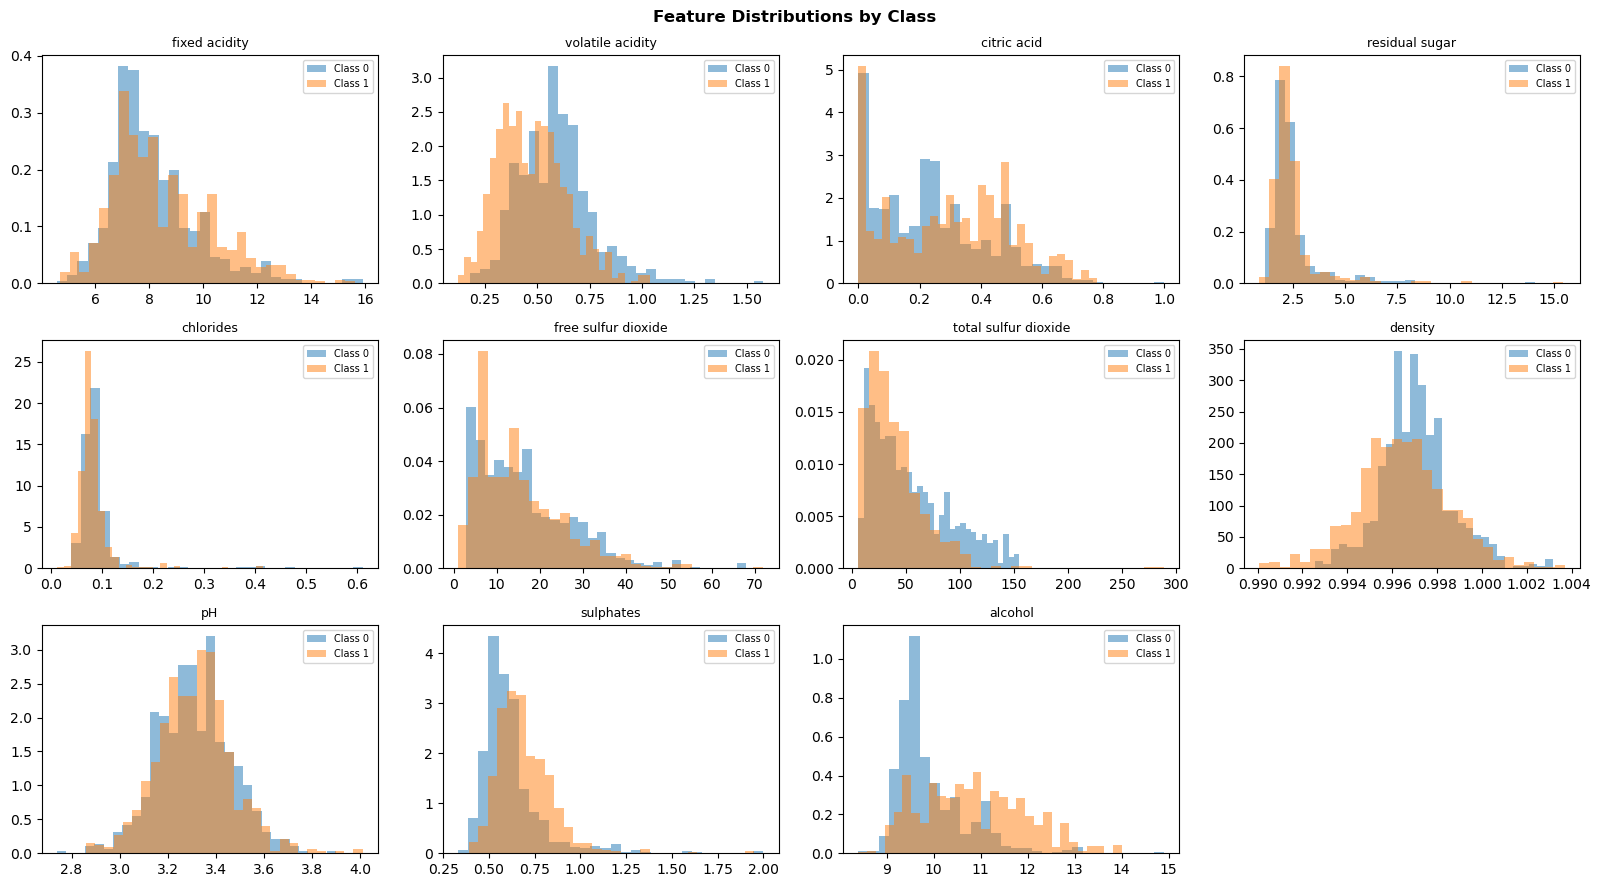

Saved: feature_distributions.png


In [8]:
features = [c for c in df.columns if c not in ('quality', 'quality_label')]

n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(features):
    for cls in sorted(df['quality_label'].unique()):
        subset = df[df['quality_label'] == cls][feat]
        axes[i].hist(subset, bins=30, alpha=0.5, label=f'Class {cls}', density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_distributions.png")

### Correlation Heatmap

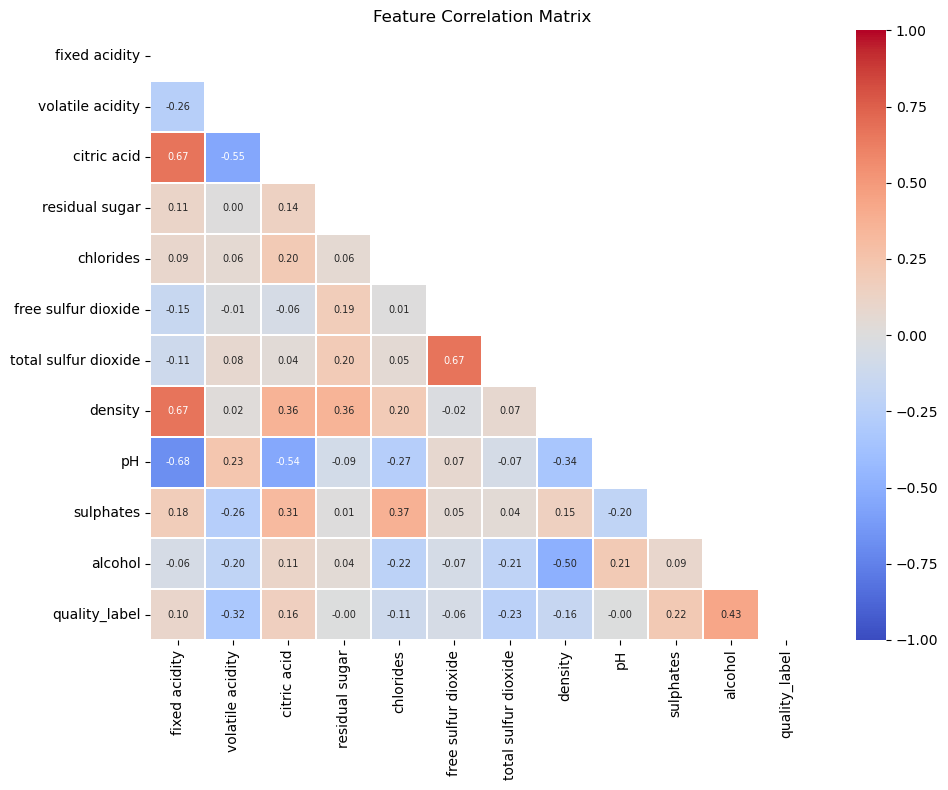


Feature correlations with 'quality_label':
alcohol                 0.435
volatile acidity       -0.321
total sulfur dioxide   -0.232
sulphates               0.218
citric acid             0.159
density                -0.159
chlorides              -0.109
fixed acidity           0.095
free sulfur dioxide    -0.062
pH                     -0.003
residual sugar         -0.002
Name: quality_label, dtype: float64


In [9]:
corr = df.drop(columns=['quality']).corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.3)
ax.set_title('Feature Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
print("\nFeature correlations with 'quality_label':")
print(corr['quality_label'].drop('quality_label').sort_values(key=abs, ascending=False).round(3))

### Feature-Target Relationship (Top Features)

Box plots of the top correlated features split by class, useful for spotting features with strong separation.

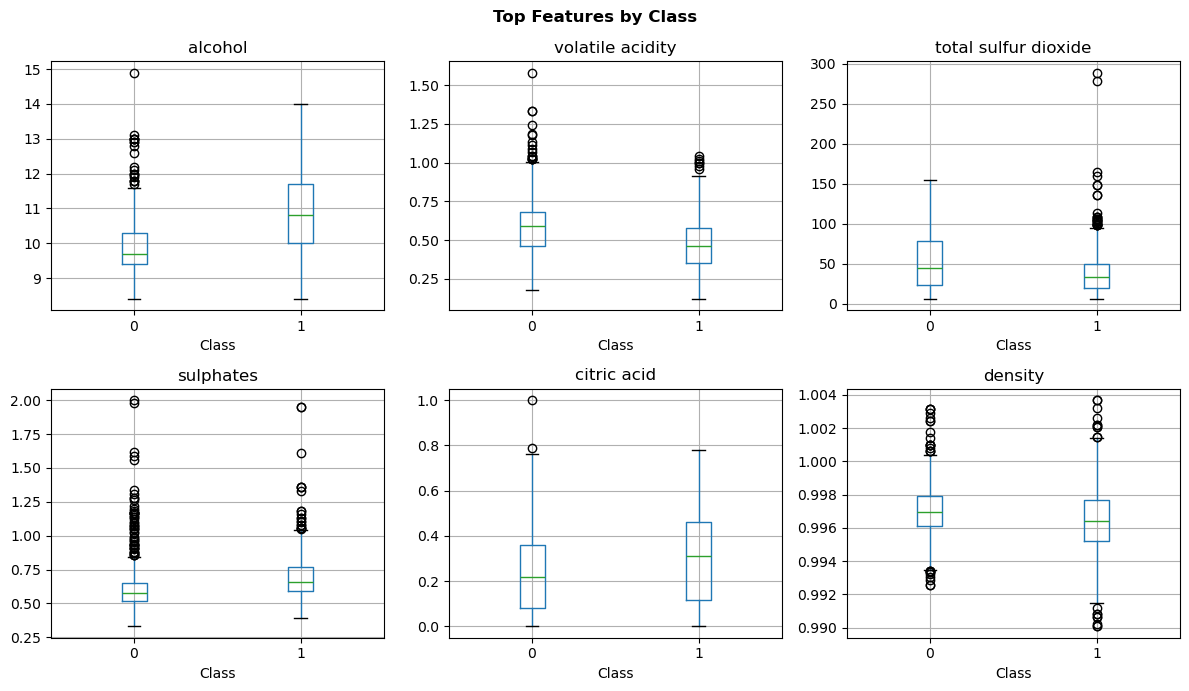

Saved: top_features_by_class.png


In [10]:
top_features = corr['quality_label'].drop('quality_label').abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    df.boxplot(column=feat, by='quality_label', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('Class')

plt.suptitle('Top Features by Class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/top_features_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_features_by_class.png")

### EDA Summary

**Shape:** 1,599 rows, 11 features

**Target:** `quality_label`, binary classification (0 = quality < 6, 1 = quality >= 6)

**Class balance:** Class 0: 46.5% / Class 1: 53.5% → balanced

**Missing values:** none

**Skewed features:** chlorides (5.68), residual sugar (4.54), sulphates (2.43), total sulfur dioxide (1.52), free sulfur dioxide (1.25)

**Strongest predictors (by correlation):** alcohol (0.435), volatile acidity (-0.321), total sulfur dioxide (-0.232)

**Key challenge:** feature engineering. Correlations with target are fairly weak individually, so combining/scaling features will likely matter more than handling imbalance.

## Train/Test Split: Holdout Locked Away

Stratified 80/20 split. `X_test`/`y_test` aren't touched again until Final Holdout Evaluation.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(y_train.value_counts(normalize=True).round(4))
print(y_test.value_counts(normalize=True).round(4))

Train: (1279, 11) | Test: (320, 11)
quality_label
1    0.5348
0    0.4652
Name: proportion, dtype: float64
quality_label
1    0.5344
0    0.4656
Name: proportion, dtype: float64


## Preprocessing Pipeline

Every model below is built through `make_pipeline`, so the imputer and scaler are fit fresh inside each CV fold rather than once on the full training set.

In [12]:
def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

## Baseline: DummyClassifier

`most_frequent` strategy, scored under the same `StratifiedKFold` CV every model below uses. This is the number every real model needs to beat.

In [13]:
baseline_pipeline = make_pipeline(DummyClassifier(strategy='most_frequent'))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_scores = cross_val_score(baseline_pipeline, X_train, y_train, cv=cv, scoring='f1')

print(f"Baseline (DummyClassifier) F1: {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}")

Baseline (DummyClassifier) F1: 0.6969 ± 0.0006


## Model Comparison: Logistic Regression, Random Forest, Gradient Boosting

Logistic Regression is the interpretable linear baseline. Random Forest and Gradient Boosting both capture non-linear interactions, which the correlation heatmap suggested would matter given how weak the individual feature correlations were. All three go through the same pipeline and CV scheme as the baseline.

In [14]:
log_reg_pipeline = make_pipeline(LogisticRegression(random_state=42))
log_reg_scores = cross_val_score(log_reg_pipeline, X_train, y_train, cv=cv, scoring='f1')
print(f"Logistic Regression F1: {log_reg_scores.mean():.4f} ± {log_reg_scores.std():.4f}")

Logistic Regression F1: 0.7605 ± 0.0161


In [15]:
rf_pipeline = make_pipeline(RandomForestClassifier(random_state=42))
rf_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='f1')
print(f"Random Forest F1: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

Random Forest F1: 0.8089 ± 0.0150


In [16]:
gb_pipeline = make_pipeline(GradientBoostingClassifier(random_state=42))
gb_scores = cross_val_score(gb_pipeline, X_train, y_train, cv=cv, scoring='f1')
print(f"Gradient Boosting F1: {gb_scores.mean():.4f} ± {gb_scores.std():.4f}")

Gradient Boosting F1: 0.7869 ± 0.0138
